<a href="https://colab.research.google.com/github/K-Tanaka8/prophet_demand_forecast/blob/main/prophet_demand_forecast_sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
'''
#  簡易需要予測サンプル (Prophet + 回帰変数)
このノートブックは、Google Colab上で動作する「Prophetによる簡易需要予測」のサンプルです。

- ダミーデータで動作確認済み
- 祝日・月末・ラグ変数を回帰として追加
- 未来予測と簡易在庫目安を可視化
- Google Colabでそのまま動かせます
- このリポジトリのコードはポートフォリオ用です。 閲覧は自由ですが、商用利用・再配布は不可です。
'''


'\n#  簡易需要予測サンプル (Prophet + 回帰変数)\nこのノートブックは、Google Colab上で動作する「Prophetによる簡易需要予測」のサンプルです。\n\n- ダミーデータで動作確認済み\n- 祝日・月末・ラグ変数を回帰として追加\n- 未来予測と簡易在庫目安を可視化\n- Google Colabでそのまま動かせます\n- このリポジトリのコードはポートフォリオ用です。 閲覧は自由ですが、商用利用・再配布は不可です。\n'

In [30]:
# 1️ ライブラリインストール & 設定
!pip install -q japanize-matplotlib prophet holidays

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
from prophet import Prophet
import holidays

import warnings
warnings.filterwarnings('ignore')

In [31]:
# 2️ ダミーデータ作成
np.random.seed(42)
dates = pd.date_range("2024-01-01", periods=180)
sales = np.random.poisson(50, len(dates)) + np.random.randint(-5,5,len(dates))

df = pd.DataFrame({"ds":dates, "y":sales})

In [32]:
# 3️ 特徴量追加
JP_HOLIDAYS = holidays.Japan(years=[2024])

df["祝日"] = df["ds"].isin(pd.to_datetime(list(JP_HOLIDAYS.keys()))).astype(int)
df["月末"] = df["ds"].dt.is_month_end.astype(int)
df["y_lag_7"] = df["y"].shift(7)
df["y_lag_7"] = df["y_lag_7"].fillna(df["y"].mean())

In [33]:
# 4️ Prophetモデル構築 & 学習
m = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)
m.add_regressor("祝日")
m.add_regressor("月末")
m.add_regressor("y_lag_7")

train_df = df[["ds","y","祝日","月末","y_lag_7"]]
m.fit(train_df)

In [34]:
# 5️ 未来予測
future = m.make_future_dataframe(periods=14)
future["祝日"] = future["ds"].isin(JP_HOLIDAYS).astype(int)
future["月末"] = future["ds"].dt.is_month_end.astype(int)
last_known_lag = df["y_lag_7"].iloc[-1]  # 直近の実績ラグ値
future["y_lag_7"] = future["ds"].map(df.set_index("ds")["y_lag_7"]).fillna(last_known_lag)

forecast = m.predict(future)
forecast["buffered_reference"] = np.ceil(forecast["yhat_upper"])

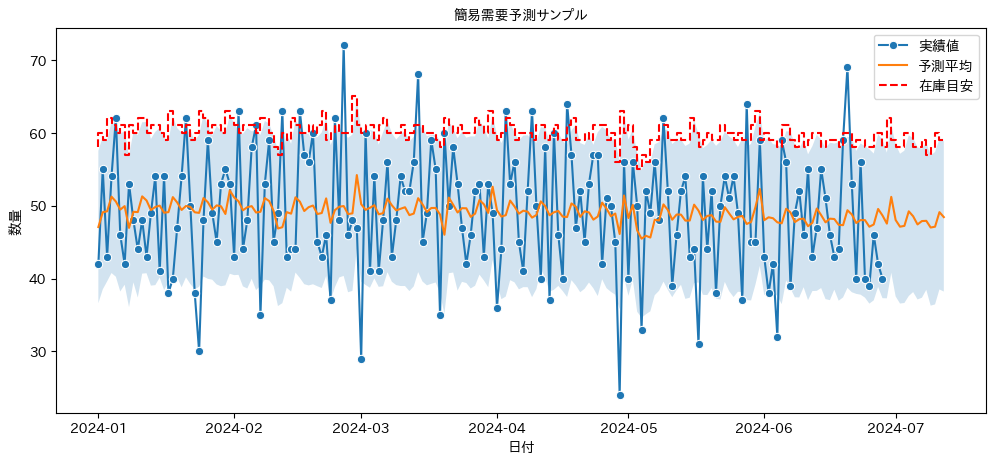

In [35]:
# 6️ 可視化
fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(x="ds", y="y", data=df, label="実績値", marker="o", ax=ax)
sns.lineplot(x="ds", y="yhat", data=forecast, label="予測平均", ax=ax)
ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"], alpha=0.2)
ax.step(forecast["ds"], forecast["buffered_reference"], label="在庫目安", color="red", linestyle="--")
ax.set_title("簡易需要予測サンプル", fontproperties=fp)
ax.set_xlabel("日付", fontproperties=fp)
ax.set_ylabel("数量", fontproperties=fp)
ax.legend(prop=fp)
plt.show()